Goal of this notebook:

1. Show the seperate steps of the prediction a a single example branch:
    1. Upsampling
    2. filtering
    3. prediction

2. Show the full prediction for a single cell

Load Seg and prune skel to a single branch

In [12]:
import bulb_detection as bd
import skeliner as sk
import matplotlib.pyplot as plt
import numpy as np
from scipy.ndimage import median_filter

In [2]:
seg_id = '720575940554533490'
skel = bd.load_skeleton('../recalibrated skeletons/' + seg_id + '_skel_recal_75.0.pkl')
ann = bd.parse_annotations_json('../revised_annotations/revised_ann_' + seg_id + '.json')

In [3]:
voxelsize = bd.io.get_layer_voxelsize(ann=ann, layer_id=3)
annotated_bulb_starts, annotated_bulb_ends = bd.io.get_annotated_bulb_coords(ann=ann, layer_id=3, voxelsize=voxelsize)

endpoint_coords = bd.io.get_endpoint_coords(ann=ann, layer_id=4, voxelsize=voxelsize)
endpoint_nodes = []
for endpoint_coord in endpoint_coords:
    endpoint_node, _ = bd.graph.coords_to_nodes(skel=skel, query_coords=endpoint_coord)
    endpoint_nodes.append(endpoint_node)
endpoint_nodes = np.array(endpoint_nodes)

# Singel branch
pruned_skel = bd.graph.prune_skeleton_from_node_ids(skel=skel, keep_node_ids=endpoint_nodes[0])

geodesic_dists_pruned = bd.graph.compute_geodesic_distances(skel=pruned_skel)
radii_pruned = pruned_skel.radii['calibrated']

Interpolate the radii to be evenly spaced

In [4]:
even_dists, even_radii = bd.signal.evenly_sample_branch(
    geodesic_dists=geodesic_dists_pruned,
    radii=radii_pruned,
    step_size=0.05
)

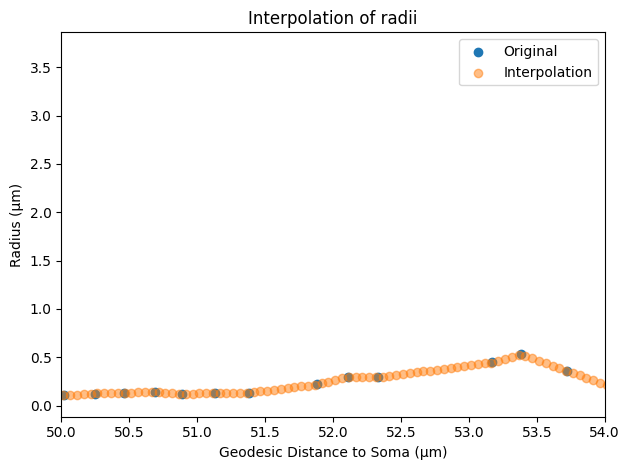

In [11]:
plt.scatter(geodesic_dists_pruned, radii_pruned, label="Original")
plt.scatter(even_dists, even_radii, label="Interpolation", alpha=0.5)
plt.xlabel("Geodesic Distance to Soma (μm)")
plt.ylabel("Radius (μm)")
plt.title(f"Interpolation of radii")
plt.xlim(50, 54)
plt.legend()
plt.tight_layout()

Median filtering (baseline substraction)

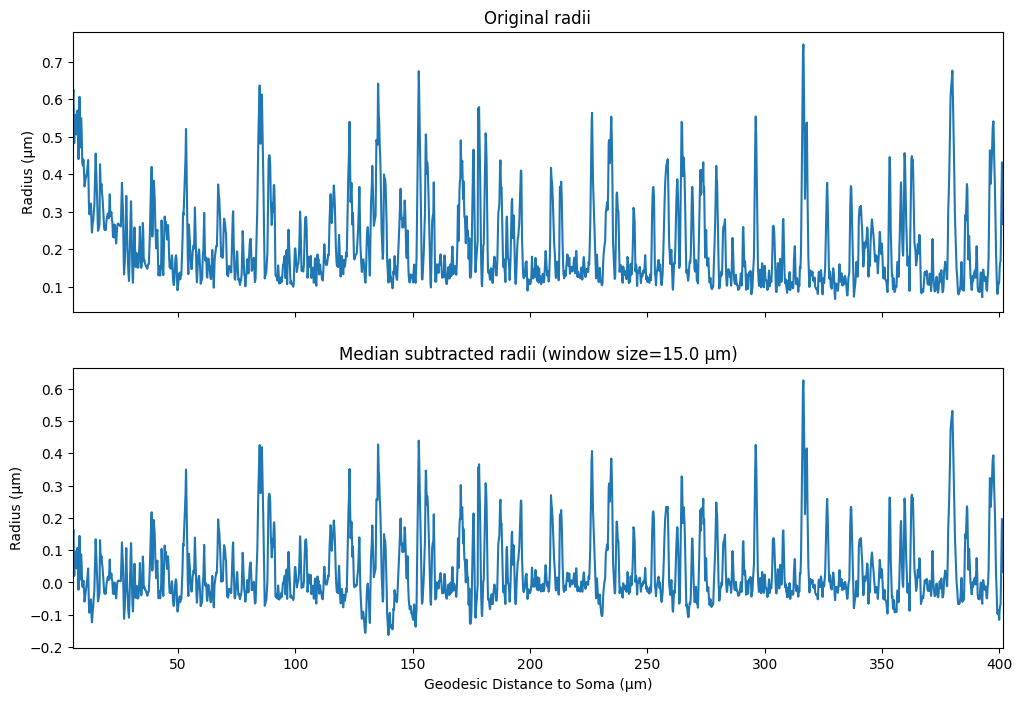

In [23]:
window_size_um = 15.
step_size = 0.05
window_samples = int(window_size_um / step_size)

baseline_radii = median_filter(even_radii, size=window_samples, mode='reflect')
radii_filtered = even_radii - baseline_radii

xmin, xmax = np.min(even_dists), np.max(even_dists)

fig, ax = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
ax[0].plot(even_dists, even_radii)
ax[0].set_ylabel('Radius (μm)')
ax[0].set_title('Original radii')
ax[0].set_xlim(xmin, xmax)

ax[1].plot(even_dists, radii_filtered)
ax[1].set_xlabel('Geodesic Distance to Soma (μm)')
ax[1].set_ylabel('Radius (μm)')
ax[1].set_xlim(xmin, xmax)
ax[1].set_title(f'Median subtracted radii (window size={window_size_um} μm)')
plt.show()

Peak detection

In [24]:
k = 2.
dynamic_threshold = bd.signal.compute_mad_threshold(radii_filtered, k=k)
print(dynamic_threshold)

0.11573429350461392


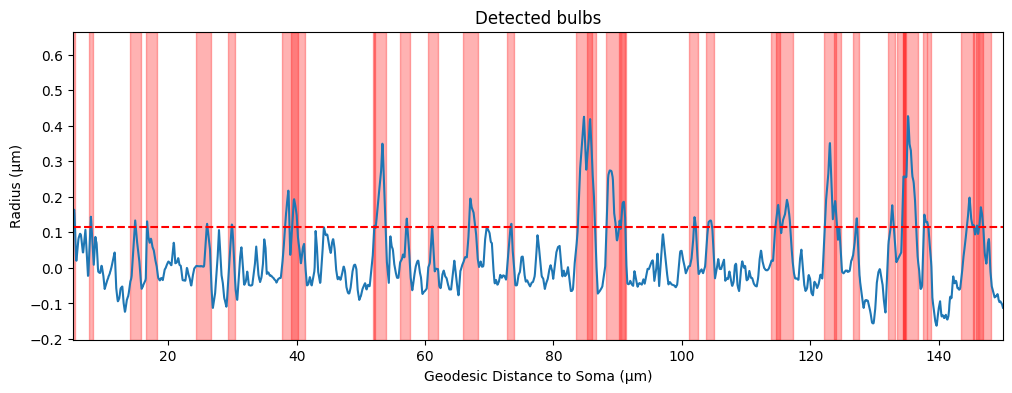

In [33]:
# The dynamic threshold computation is done in detect_branch_peaks automatically
peak_spans, dynamic_threshold = bd.signal.detect_branch_peaks(
    even_dists=even_dists,
    even_radii=even_radii,
    window_size=15,
    k=k
)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(even_dists, radii_filtered)
ax.axhline(dynamic_threshold, color='red', linestyle='--')

for start_dist, end_dist in peak_spans:
    ax.axvspan(start_dist, end_dist, color='red', alpha=0.3)

ax.set_ylabel('Radius (μm)')
ax.set_xlabel('Geodesic Distance to Soma (μm)')
ax.set_title('Detected bulbs')
ax.set_xlim(xmin, 150)

plt.show()

Run full detection and show the bulbs on the 2d skel

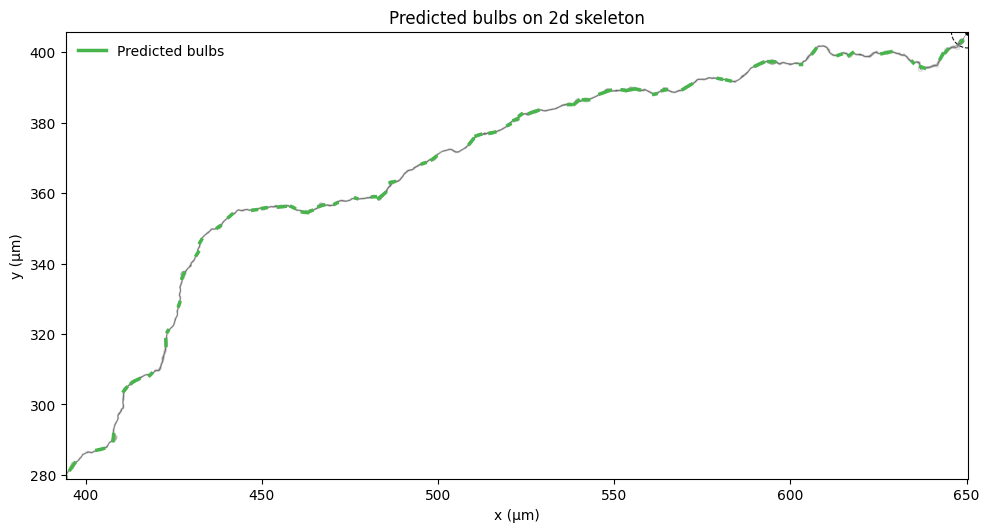

In [36]:
predicted_bulb_clusters, predicted_bulb_coords, branch_thresholds = bd.signal.predict_bulbs(
    skel=pruned_skel,
    geodesic_dists=geodesic_dists_pruned,
    radii=radii_pruned,
    window_size=15.0,
    k=2.0
)

start_dists = np.array([c[0] for c in predicted_bulb_coords])
end_dists = np.array([c[1] for c in predicted_bulb_coords])

ax = bd.visualization.plot_anns_on_skeleton(
    skel=pruned_skel,
    ann_stars=start_dists,
    ann_ends=end_dists,
    ann_color='#48b54c',
    label='Predicted bulbs',
    title='Predicted bulbs on 2d skeleton'
)

Merging split bulbs

In [39]:
merged_bulb_clusters = bd.signal.merge_split_clusters(
    skel=pruned_skel,
    geodesic_dists=geodesic_dists_pruned,
    clusters=predicted_bulb_clusters,
    merge_threshold_um=1.0
)

print(f'Original predictions: {len(predicted_bulb_clusters)}')
print(f'Predictions after merging: {len(merged_bulb_clusters)}')

Original predictions: 63
Predictions after merging: 58
